In [9]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import random

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, SubsetRandomSampler

from sklearn.model_selection import train_test_split

import dlib
import cv2
import face_recognition
import sys

from PIL import UnidentifiedImageError
from PIL import Image

from insightface import app
from tqdm.autonotebook import tqdm as tqdm

# LFW (Labelled Faces in the Wild (LFW) Dataset

In [29]:
data_dir_path = 'LFW (Labelled Faces in the Wild (LFW) Dataset)'
os.makedirs(data_dir_path , exist_ok = True)
all_files = os.listdir(data_dir_path)
image_dir = os.path.join(data_dir_path, 'lfw-deepfunneled', 'lfw-deepfunneled')

# check how many people are there in the dataset
persons = os.listdir(image_dir)
num_classes = len(persons)

In [30]:
persons_df = pd.DataFrame(persons)
persons_df.reset_index(drop=True)

,0
0,German_Khan
1,Stefano_Gabbana
2,Dragan_Covic
3,Jeff_Hornacek
4,Sureyya_Ayhan
...,...
5745,Li_Zhaoxing
5746,Sherry_Fisher
5747,John_Garamendi
5748,Roger_King


In [31]:
# Randomly select one person and list their images
selected_person = random.choice(persons)
person_images = os.listdir(os.path.join(image_dir, selected_person))

image_properties = []
for img_name in person_images:
    img_path = os.path.join(image_dir, selected_person, img_name)
    img = Image.open(img_path)
    image_properties.append((img_name, img.size, img.format))
image_properties

[('Vin_Diesel_0001.jpg', (250, 250), 'JPEG'),
 ('Vin_Diesel_0002.jpg', (250, 250), 'JPEG')]

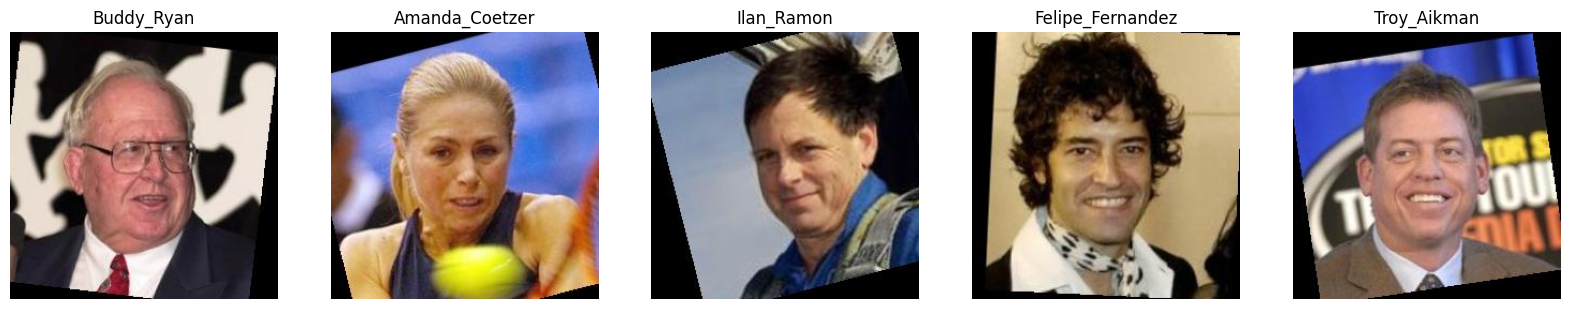

In [40]:
random_people = random.sample(persons, 5)
# show random people images
sample_images = []
for person in random_people:
    # print(image_dir, person)
    person_image_dir = os.path.join(image_dir, person)
    person_image_file = os.listdir(person_image_dir)
    selected_image = random.choice(person_image_file)
    sample_images.append(os.path.join(person_image_dir,selected_image))

fig, ax = plt.subplots(1, 5, figsize=(20, 20))
for i, image_path in enumerate(sample_images):
    img = plt.imread(image_path)
    ax[i].imshow(img)
    ax[i].set_title(sample_images[i].split('/')[-2])  # Title with the person's name
    ax[i].axis('off')
plt.show()

<Figure size 1200x1200 with 0 Axes>

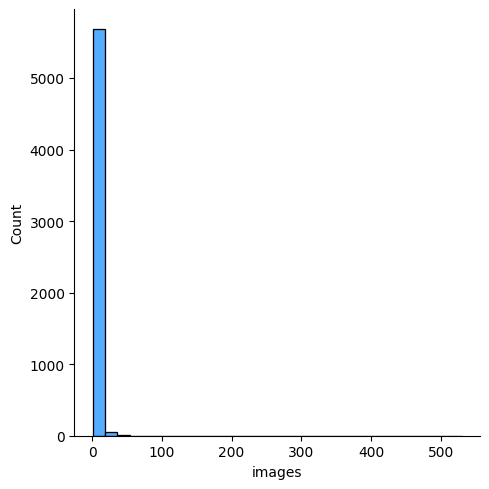

In [10]:
# check distribution of images by person
person_per_image = pd.read_csv('LFW (Labelled Faces in the Wild (LFW) Dataset)/lfw_allnames.csv')
plt.figure(figsize=(12, 12))
sns.displot(x=person_per_image['images'], bins=30, color='dodgerblue')
plt.show()

In [11]:
person_per_image.describe()

,images
count,5749.000000
mean,2.301792
std,9.016410
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,530.000000


# 105 pins

In [45]:
img_dir_path = '105_classes_pins_dataset'
os.makedirs(img_dir_path , exist_ok = True)
all_files = os.listdir(img_dir_path)

In [46]:
persons = os.listdir(img_dir_path)
num_classes = len(persons)
person_list = []
for name in persons:
    name = name.lower().split('pins_')
    if name != ['.ds_store']:
        person_list.append(name[1])

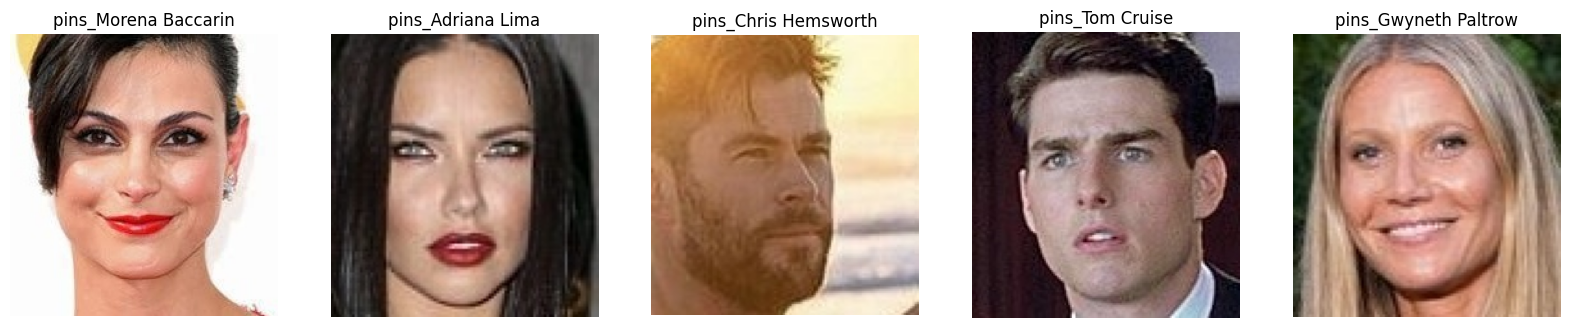

In [50]:
selected_person = random.choice(os.listdir(img_dir_path))
person_images = os.listdir(os.path.join(img_dir_path, selected_person))
random_people = random.sample(persons, 5)
sample_images = []

for person in random_people:
    person_img_dir = os.path.join(img_dir_path, person)
    person_image_file = os.listdir(person_img_dir)
    # print('person_image_file', person_image_file)
    sample_image = random.choice(person_image_file)

    # print('person_img_dir, sample_image', person_img_dir, sample_image)
    sample_images.append(os.path.join(person_img_dir,sample_image))
fig, ax = plt.subplots(1, 5, figsize=(20, 20))
for i, image_path in enumerate(sample_images):
    img = plt.imread(image_path)
    ax[i].imshow(img)
    ax[i].set_title(sample_images[i].split('/')[-2])  # Title with the person's name
    ax[i].axis('off')
plt.show()

In [21]:
total_images_per_person = []
for person_folder in all_files:
    if person_folder != '.DS_Store':
        person_images = os.listdir(os.path.join(img_dir_path, person_folder))
        total_images_per_person.append(len(person_images))

In [22]:
max(total_images_per_person)

237

In [23]:
min(total_images_per_person)

86

In [25]:
np.mean(total_images_per_person)

166.9904761904762

(array([ 1.,  2.,  1.,  2.,  2.,  5.,  4.,  4.,  5.,  3.,  3.,  6., 10.,
         6.,  4., 11.,  6.,  6.,  6.,  4.,  6.,  2.,  2.,  2.,  2.]),
 array([ 86.  ,  92.04,  98.08, 104.12, 110.16, 116.2 , 122.24, 128.28,
        134.32, 140.36, 146.4 , 152.44, 158.48, 164.52, 170.56, 176.6 ,
        182.64, 188.68, 194.72, 200.76, 206.8 , 212.84, 218.88, 224.92,
        230.96, 237.  ]),
 <BarContainer object of 25 artists>)

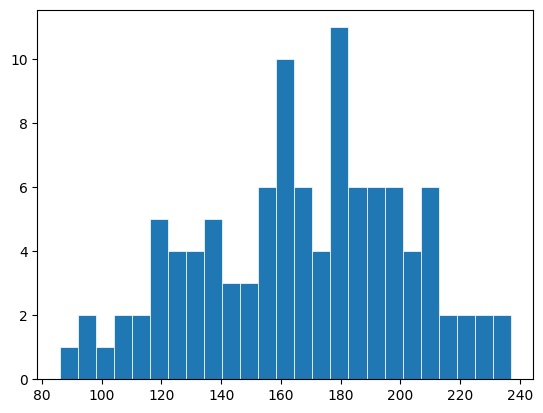

In [26]:
plt.hist(total_images_per_person, bins=25, linewidth=0.5, edgecolor="white")